# scvxplots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as mat
import scipy.linalg as smat

import _pickle as cPickle
with open(r"plot_struct.pkl", "rb") as input_file: data0 = cPickle.load(input_file)
data = data0['plot_struct']


In [4]:
class SCVXPLOTS:
    def __init__(self,data):
        self.data = data;
        self.scenarios = list(self.data); self.methods = {};
        for tag in self.scenarios: self.methods[tag] = list(self.data[tag]);
        self.base_pen = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-'}
        
    def addPlot2D(self,ax,pen={},typ='line',tags={}):
        if len(pen)==0: pen = self.base_pen;
        scenario = self.scenarios[0];
        if 'scenario' in tags: scenario = tags['scenario'];
        method = self.methods[scenario][0];
        if 'method' in tags: method = tags['method'];
        runs = [0]; iters = [0];
        if 'runs' in tags: runs = tags['runs'];
        if 'iters' in tags: iters = tags['iters'];

        xtag = None; ytag = None;
        if 'x' in tags: xtag = tags['x'];
        if 'y' in tags: ytag = tags['y'];

        for r in runs:
            RUNS = self.data[scenario][method]['runs'];
            if r < len(RUNS):
                RUN = RUNS[r];
                for i in iters:
                    if i < len(RUN['iters']):
                        data = RUN['iters'][i];
                        if not(ytag == None):
                            if isinstance(ytag,tuple): ydata = data[ytag[0]][:,ytag[1]];
                            else: ydata = data[ytag];
                            if xtag == None:
                                xdata = list(range(len(ydata)));
                            else:
                                if isinstance(xtag,tuple): xdata = data[xtag[0]][:,xtag[1]];
                                else: xdata = data[xtag];

                            frgba = pen['frgba']; lrgba = pen['lrgba'];
                            lw = pen['lw']; ls = pen['ls']
                            if typ == 'line':
                                ax.plot(xdata,ydata,color=lrgba[:3],alpha=lrgba[3],linewidth=lw,linestyle = ls)


    def genGridTags(self,fig,typ=None,params={}):
        return self.createGrid(fig,typ=typ,grid=self.specGrid(typ=typ,params=params));
    def specGrid(self,typ=None,params={}):
        grid = {};
        if typ=='2x2':
            grid[0] = [0.05,0.05,0.45,0.45];
            grid[1] = [0.05,0.55,0.45,0.45];
            grid[2] = [0.55,0.05,0.45,0.45];
            grid[3] = [0.55,0.55,0.45,0.45];
        return grid; 
    def createGrid(self,fig,typ='manual',grid={}):
        if typ=='manual':
            axs = {};
            for tag in grid: axs[tag] = fig.add_axes(grid[tag])
        return axs;

            


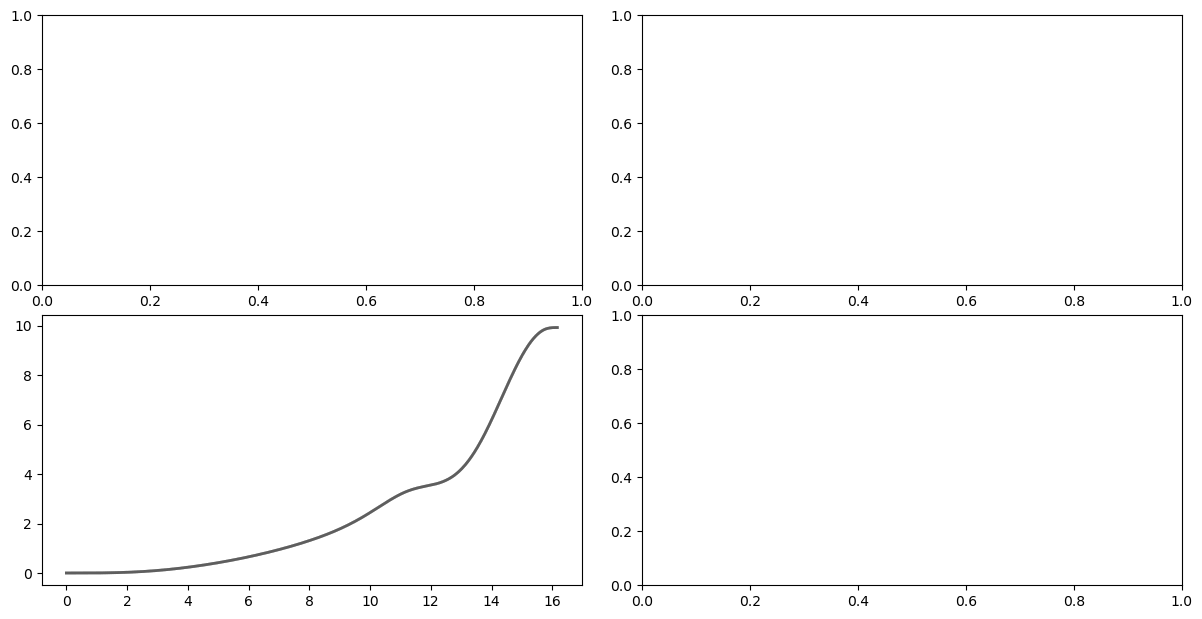

In [5]:
PENS = {};
PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-'}

fig = plt.figure(figsize=(12,6));


# fields = ['t_nl', 'z_nl', 'u_nl', 't_ref', 'z_ref', 'u_ref', 't', 'z', 'u', 'weights', 'conv_data']
PLTS1 = SCVXPLOTS(data);
grid = PLTS1.specGrid(typ='2x2');
axs = PLTS1.createGrid(fig,grid = grid);
# axs = PLTS1.genGrid(fig,typ='2x2');

runs = [0,1,2,3,4]; iters = [0,1,2,3,4,5,6,7,8,9];
base1_tags = {'scenario':'scenario1','method':'method1'};
base2_tags = {'runs':runs,'iters':iters};

PLTS1.addPlot2D(axs[0],pen=PENS['z'],tags={**base1_tags,**base2_tags,'x':'t_nl','y':('z_nl',0)})





